In [ ]:
from src.data_preprocessing import process_file
import yaml

import numpy as np
import matplotlib.pyplot as plt
from src.electrical_signature_frequencies import ANOMALY_FREQS

In [6]:
with open('../engine_configs/LIMAN.yml', 'r') as f:
    engine_config = yaml.safe_load(f)

# Processing Parameters
f_sampling = 10000
shift = 20
segment_length = 10000
cutoff_freq = 250
peak_type = 'gaussian'
peak_segment = 6
amplitude_range = (5.0, 10.0)

file_label_map = {
    '../data/raw/0702 без перекосов фаза A.txt': 'normal',
    '../data/raw/0702  межвитковые фазы A ток фазы А.txt': 'inter-turn short circuits',
    '../data/raw/20_01_1460_об_мин_с_дисбалансом_ротора.txt': 'rotor bar defect'
}

fault_types_available = [
    'rotor bar defect',
    'inter-turn short circuits'
]

In [59]:
def get_average_spectrum(segs):
    return np.mean(segs, axis=0)

def get_spectrum_std(segs):
    return np.std(segs, axis=0)

def plot_average_spectrum(ax, segs, freqs, label='Average Spectrum'):
    avg_spectrum = get_average_spectrum(segs)

    ax.plot(freqs, avg_spectrum, linewidth=2.0, color='blue', label=label)
    return ax

def plot_spectrum_std(ax, segs, freqs, n_std=3):
    avg_spectrum = get_average_spectrum(segs)
    spectrum_std = get_spectrum_std(segs)

    ax.fill_between(
        freqs,
        avg_spectrum - spectrum_std,
        avg_spectrum + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )
    # Add thicker boundary lines for the shaded region
    ax.plot(freqs, avg_spectrum - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(freqs, avg_spectrum + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    return ax

def draw_signature_lines(ax, freqs):
        for freq in freqs:
            if freq > 0:
                ax.axvline(x=freq, color='red', linestyle='--', linewidth=1.0)


In [27]:
label_file_map = {v: k for k, v in file_label_map.items()}
label_segs_map = {}

for v, k in label_file_map.items():
    label_segs_map[v], _, freqs = process_file(k, engine_config, v,
                                     f_sampling=f_sampling, cutoff_freq=cutoff_freq,
                                     segment_length=segment_length, peak_segment=peak_segment, step=shift,
                                     apply_window=False, db=True,
                                     synthetic_fault_fraction=0.0, fault_types=None, amplitude_range=amplitude_range)

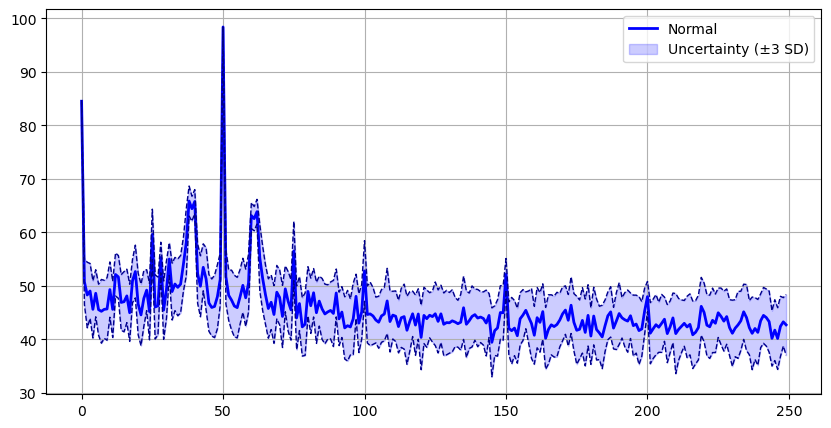

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_average_spectrum(fig, ax, label_segs_map['normal'], freqs, label='Normal')
plot_spectrum_std(fig, ax, label_segs_map['normal'], freqs, n_std=3, label='Normal')
plt.legend()
plt.grid()
plt.show()

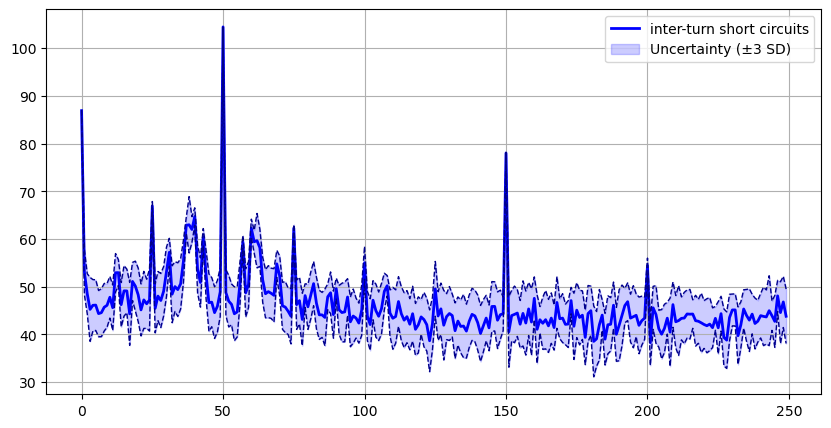

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_average_spectrum(fig, ax, label_segs_map['inter-turn short circuits'], freqs, label='inter-turn short circuits')
plot_spectrum_std(fig, ax, label_segs_map['inter-turn short circuits'], freqs, n_std=3, label='inter-turn short circuits')
plt.legend()
plt.grid()
plt.show()

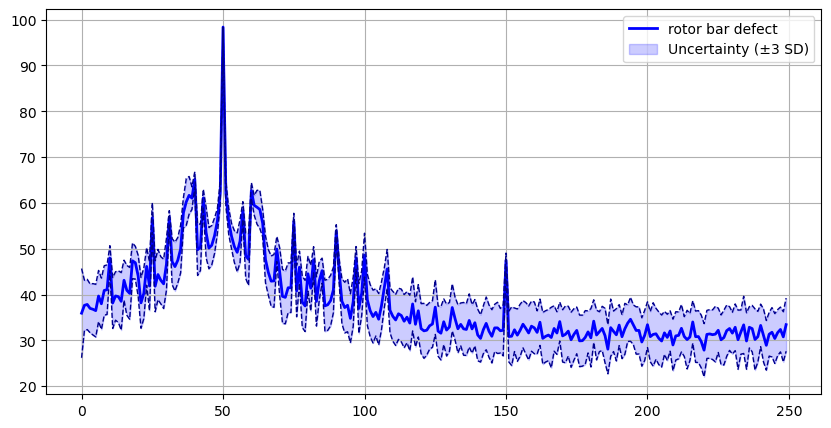

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_average_spectrum(fig, ax, label_segs_map['rotor bar defect'], freqs, label='rotor bar defect')
plot_spectrum_std(fig, ax, label_segs_map['rotor bar defect'], freqs, n_std=3, label='rotor bar defect')
plt.grid()
plt.legend()
plt.show()

## Deltas

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_average_spectrum(fig, ax, label_segs_map['normal'], freqs, label='Normal')
plot_spectrum_std(fig, ax, label_segs_map['normal'], freqs, n_std=3, label='Normal')
plt.legend()
plt.grid()
plt.show()

In [46]:
normal_segs = label_segs_map['normal']
itsc_segs = label_segs_map['inter-turn short circuits']
rbd_segs = label_segs_map['rotor bar defect']

In [49]:
delta_itsc = itsc_segs - normal_segs[:itsc_segs.shape[0], :]
delta_rbd = rbd_segs - normal_segs[:rbd_segs.shape[0], :]

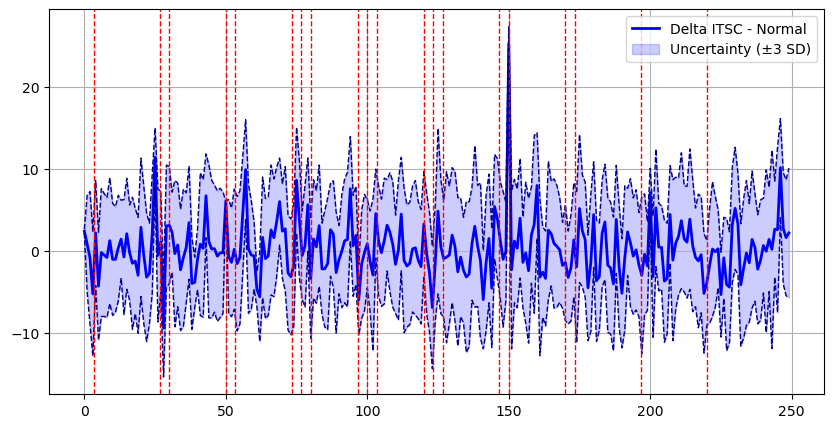

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))

fault_freqs = ANOMALY_FREQS.get('inter-turn short circuits', lambda ec: [])(engine_config)
plot_average_spectrum(ax, delta_itsc, freqs, label='Delta ITSC - Normal')
plot_spectrum_std(ax, delta_itsc, freqs, n_std=3)
draw_signature_lines(ax, fault_freqs)
plt.legend()
plt.grid()
plt.show()

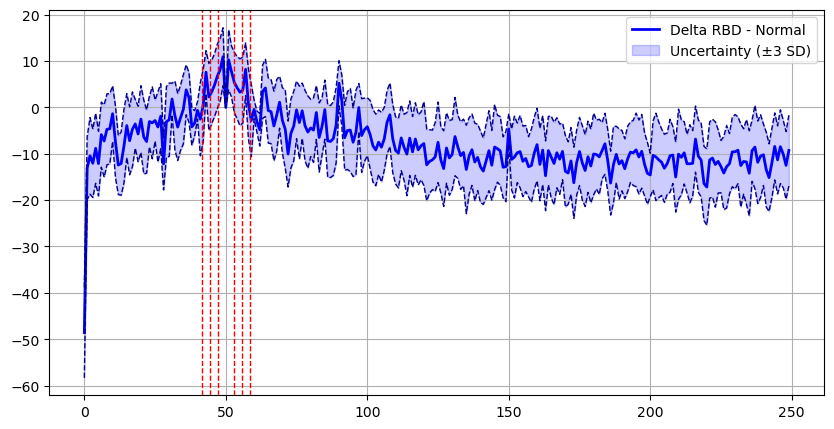

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))


fault_freqs = ANOMALY_FREQS.get('rotor bar defect', lambda ec: [])(engine_config)
plot_average_spectrum(ax, delta_rbd, freqs, label='Delta RBD - Normal')
plot_spectrum_std(ax, delta_rbd, freqs, n_std=3)
draw_signature_lines(ax, fault_freqs)
plt.legend()
plt.grid()
plt.show()